In [37]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from langchain.tools import tool
load_dotenv()

if os.environ['GOOGLE_API_KEY'] == "":
    raise ValueError("GOOGLE_API_KEY is not set in the .env file.")
else:
    print("GOOGLE_API_KEY is set correctly.")

GOOGLE_API_KEY is set correctly.


In [38]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash",)
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 3.5 Flash', 'release_date': '2026-05-19', 'last_updated': '2026-05-19', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.5-flash', temperature=1.0, client=<google.genai.client.Client object at 0x00000178EC770FD0>, default_metadata=(), model_kwargs={})

In [39]:
from pydantic import BaseModel, Field
from typing import List

class llm_schema(BaseModel):
    tasks: List[str] = Field(..., description="A list of tasks to be performed by the worker.")

llm_with_schema = llm.with_structured_output(llm_schema)

In [40]:
from typing import TypedDict

class graph_schema(TypedDict):
    tasks: List[str]
    query: str
    results: List[str]
    summary: str

In [41]:
from langchain_core.prompts import ChatPromptTemplate

def orchestrator_node(state: graph_schema) -> graph_schema:
    user_query = state['query']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are an orchestrator that breaks down a user query into tasks for the worker."),
            ("user", f"User query: {user_query}. Please generate one prompt per task for the worker to complete.")
        ]
    )

    chain = prompt | llm_with_schema

    response = chain.invoke({"query": user_query})

    state["tasks"] = response.tasks
    return state

In [42]:
# execute function


def execute(query: str):
    response = llm.invoke(query)
    return response

In [43]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state: graph_schema) -> graph_schema:
    tasks = state['tasks']
    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        results_futures = executor.map(execute, tasks)

        for result in results_futures:
            results.append(result)

    state['results'] = results
    return state

In [44]:
def collector_node(state: graph_schema) -> graph_schema:
    results = state['results']
    print(results)

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes the results from the worker."),
            ("user", "Here are the results from the worker:\n\n{results}\n\nPlease summarize these results in a concise manner.")
        ]
    )

    chain = prompt | llm

    summary = chain.invoke({"results": results})

    state['summary'] = summary
    return state

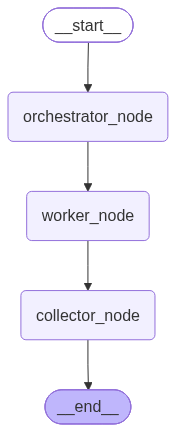

In [45]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("orchestrator_node", orchestrator_node)
graph.add_node("worker_node", worker_node)
graph.add_node("collector_node", collector_node)

graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph = graph.compile()

from IPython.display import Image, display
Image(complex_graph.get_graph().draw_mermaid_png())

In [46]:
complex_graph.invoke(
    {
        "query": "what is the capital of France? name 5 tropical fruits. what is the best medicine for influenza?",
        "tasks": [],
        "results": [],
        "summary": ""
    }
)

[AIMessage(content=[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'EpoDCpcDARFNMg+/Ajuu1OsKRJVXu8dXZbEi2r/01LSeXOnMfQbVQ+7Q/l5dgDDZzW/91XO3IP/8j1RVYZI0AqoPVGtiUDHDCfWHMMwu/5d5XnOrYsBUx5NSRRCJn9tCvv1T5kNdCNpoi2RqrN/z1cn+3/iIOExZ9vw6rI0lLOJYGu3TP4MXdg6pRGIG28hz/ugcdXRAGnM8xZJOysLLvopcb4Bt3zy2U+FcAX6j6K8+WRWeQ+2IPXWHgZoYYPRCo47SYIFKEuSxKrQaVCuJQYMgVYS4NSjKViD5lXWvAnhJsgTv7RPZc5mnxsVX0gqo0YrwO3h+Yc5A0I6lgLY/bDCGALPlCsj4meflb8Ubqj5JoqXaMbHFHInSaeU71AmB6ZcHgKCfKPmP9fBOO+6JkvMjdUrzqk+4R9CjtNOoWM3Uk/my8RxFn8Zh+QJZSo3P/ryhheWdNrRxqhYamPvJyS38x6z4ada7eeJOnuu+brw2+18fZw3BYch53Gv36DE7tsfmv0gGf9/Dz/WnjSkl4N9WmBrT9swNpDzM9ZA='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f744e-9233-79a1-8374-5a858c9b4a15-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 93, 'total_tokens': 101, 'input_t

{'tasks': ['What is the capital of France?',
  'Name 5 tropical fruits.',
  'What is the best medicine for influenza?'],
 'query': 'what is the capital of France? name 5 tropical fruits. what is the best medicine for influenza?',
 'results': [AIMessage(content=[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'EpoDCpcDARFNMg+/Ajuu1OsKRJVXu8dXZbEi2r/01LSeXOnMfQbVQ+7Q/l5dgDDZzW/91XO3IP/8j1RVYZI0AqoPVGtiUDHDCfWHMMwu/5d5XnOrYsBUx5NSRRCJn9tCvv1T5kNdCNpoi2RqrN/z1cn+3/iIOExZ9vw6rI0lLOJYGu3TP4MXdg6pRGIG28hz/ugcdXRAGnM8xZJOysLLvopcb4Bt3zy2U+FcAX6j6K8+WRWeQ+2IPXWHgZoYYPRCo47SYIFKEuSxKrQaVCuJQYMgVYS4NSjKViD5lXWvAnhJsgTv7RPZc5mnxsVX0gqo0YrwO3h+Yc5A0I6lgLY/bDCGALPlCsj4meflb8Ubqj5JoqXaMbHFHInSaeU71AmB6ZcHgKCfKPmP9fBOO+6JkvMjdUrzqk+4R9CjtNOoWM3Uk/my8RxFn8Zh+QJZSo3P/ryhheWdNrRxqhYamPvJyS38x6z4ada7eeJOnuu+brw2+18fZw3BYch53Gv36DE7tsfmv0gGf9/Dz/WnjSkl4N9WmBrT9swNpDzM9ZA='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5